In [ ]:
pip install pandas matplotlib seaborn

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional style for the charts
sns.set_theme(style="whitegrid")

In [12]:
# Load your uploaded dataset
df = pd.read_csv('NKE.csv')

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Create helper columns for better analysis
df['Year'] = df['Date'].dt.year
df['Price_Volatility'] = df['High'] - df['Low']

# Focus on the last 5 years to make trends easier to see
recent_df = df[df['Year'] >= 2020].copy()

print("Dataset Loaded. Showing the first 5 rows:")
print(recent_df.head())

Dataset Loaded. Showing the first 5 rows:
           Date      Close       High        Low       Open   Volume  Year  \
5031 2020-01-02  94.273277  94.282504  93.184799  93.498432  5644100  2020   
5032 2020-01-03  94.014999  94.088796  92.529872  92.788154  4541800  2020   
5033 2020-01-06  93.931976  93.941196  93.046436  93.120225  4612400  2020   
5034 2020-01-07  93.885864  94.771405  92.991097  93.913536  6719900  2020   
5035 2020-01-08  93.673698  94.217934  93.027987  93.452308  4942200  2020   

      Price_Volatility  
5031          1.097705  
5032          1.558924  
5033          0.894760  
5034          1.780308  
5035          1.189947  


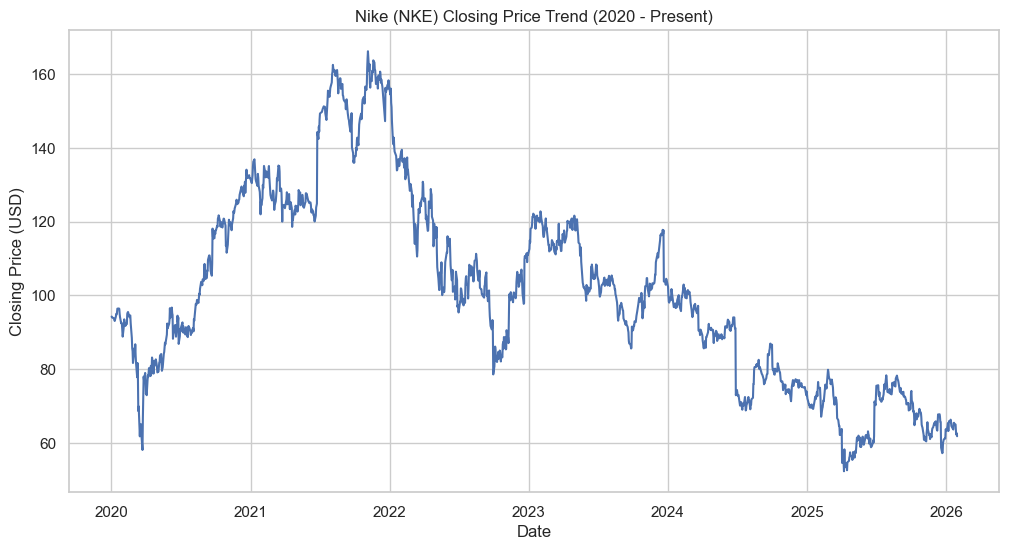

In [14]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=recent_df, x='Date', y='Close')
plt.title('Nike (NKE) Closing Price Trend (2020 - Present)')
plt.ylabel('Closing Price (USD)')
plt.show()

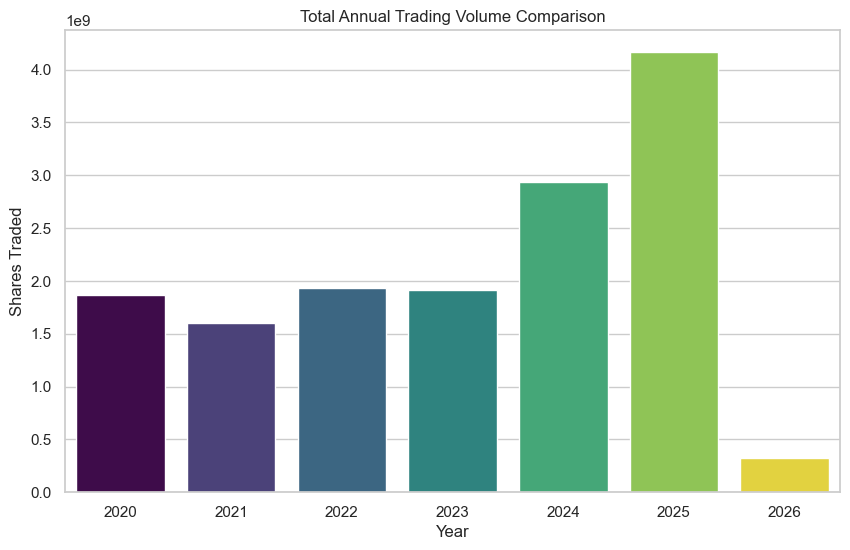

In [16]:
plt.figure(figsize=(10, 6))
# Calculate total volume per year
yearly_volume = recent_df.groupby('Year')['Volume'].sum().reset_index()

# Fix: Added hue='Year' and legend=False to remove the FutureWarning
sns.barplot(data=yearly_volume, x='Year', y='Volume', hue='Year', palette='viridis', legend=False)

plt.title('Total Annual Trading Volume Comparison')
plt.ylabel('Shares Traded')
plt.show()

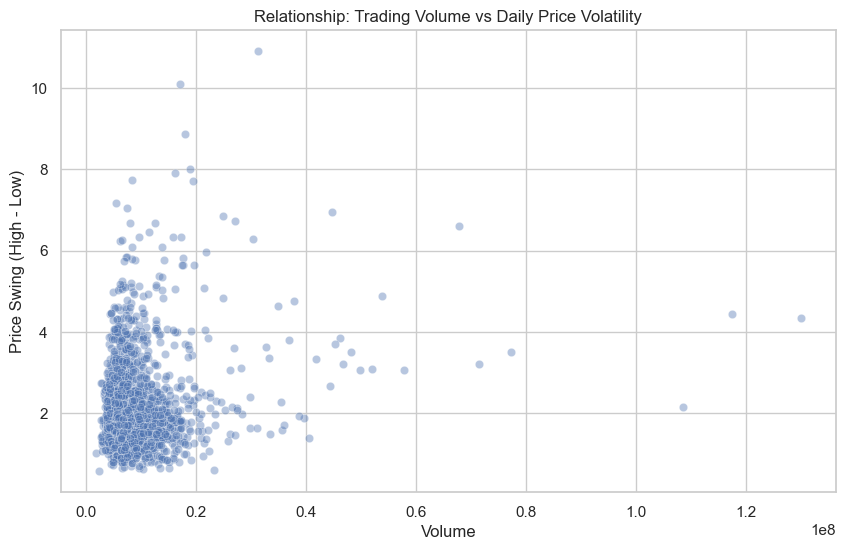

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=recent_df, x='Volume', y='Price_Volatility', alpha=0.4)
plt.title('Relationship: Trading Volume vs Daily Price Volatility')
plt.xlabel('Volume')
plt.ylabel('Price Swing (High - Low)')
plt.show()

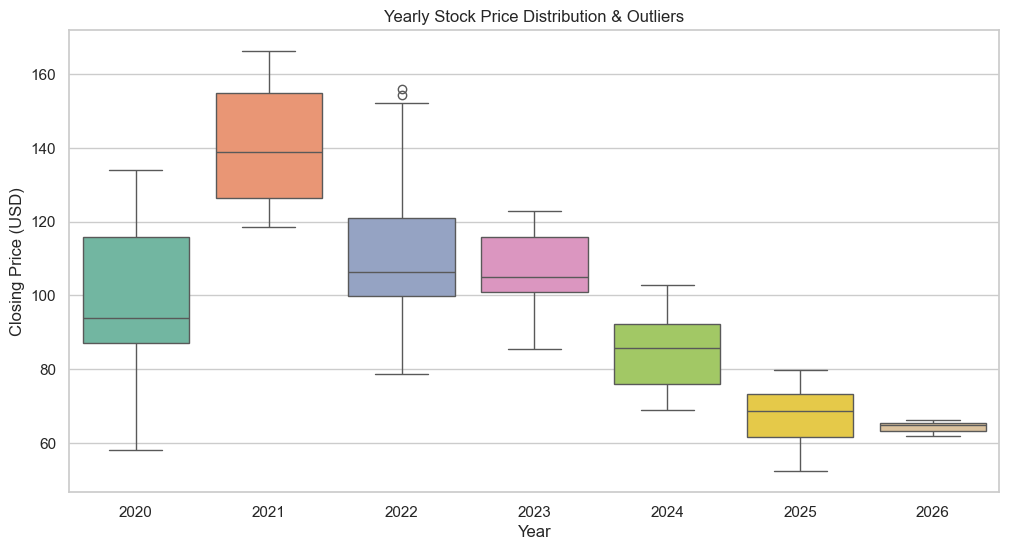

In [18]:
plt.figure(figsize=(12, 6))

# Fix: Added hue='Year' and legend=False
sns.boxplot(data=recent_df, x='Year', y='Close', hue='Year', palette='Set2', legend=False)

plt.title('Yearly Stock Price Distribution & Outliers')
plt.ylabel('Closing Price (USD)')
plt.show()